### Imports

In [1]:
!pip install transformers

In [2]:
import torch
from tqdm.notebook import tqdm

from torch.utils.data import TensorDataset

from google.colab import drive
import pandas as pd

import nltk
import re
import numpy as np
nltk.download('wordnet')
nltk.download('stopwords')
from nltk.corpus import stopwords
from  nltk.stem import SnowballStemmer

import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib as mpl

from sklearn.model_selection import train_test_split
from sklearn.utils import compute_class_weight

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


### Data Load

In [ ]:
# drive.mount('/content/drive')
path = '/kaggle/input/app-corp-split-data/'
df = pd.read_csv(path + 'APP_CORP_SPLIT_DATA.csv')
# df = pd.read_csv(path + 'APP_CORP_BACKTRASLATION.csv')
# df = pd.read_csv(path + 'APP_CORP_BACKTRASLATION_V2.csv')
# df = pd.read_csv(path + 'APP_CORP_BACKTRASLATION_V3_CHINO.csv')
# df = pd.read_csv(path + 'BINARY_APP_CORP_user_right_and_control.csv')
print(df.shape)

(16333, 4)


In [3]:
drive.mount('/content/drive')
path = '/content/drive/MyDrive/Memoria_Group_Classification/Datos/'
# df = pd.read_csv(path + 'APP_CORP_SPLIT_DATA.csv')
# df = pd.read_csv(path + 'APP_CORP_BACKTRASLATION.csv')
# df = pd.read_csv(path + 'APP_CORP_BACKTRASLATION_V2.csv')
# df = pd.read_csv(path + 'APP_CORP_BACKTRASLATION_V3_CHINO.csv')
df = pd.read_csv(path + 'APP_CORP_BT_EN_FR_3CLASS.csv')
print(df.shape)

Mounted at /content/drive
(17338, 5)


In [4]:
labels_ = [
  'policy_introductory',
  'cookies_and_similar_technologies',
  'third_party_share_and_collection',
  'user_right_and_control',
  'data_security',
  'data_retention',
  'international_data_transfer',
  'specific_audiences',
  'policy_change',
  'policy_contact_information']

In [5]:
label_dict = ['policy_introductory',
            'first_party_collection_and_use',
            'cookies_and_similar_technologies',
            'data_retention',
            'third_party_share_and_collection',
            'data_security',
            'international_data_transfer',
            'user_right_and_control',
            'specific_audiences',
            'policy_change',
            'policy_contact_information']

### Downsampling the majority class

In [6]:
# class_counts = df['label'].value_counts()
# majority_class = class_counts.idxmax()

# majority_class_df = df[(df['label'] == majority_class) & (df['data_type'] == 'train')]
# downsampled_majority_class_df = majority_class_df.sample(n=2300, random_state=42)

# conjuntos = ['val', 'test']

# major_test_val = df[(df['label'] == majority_class) & (df['data_type'].isin(conjuntos))]

# balanced_df = pd.concat([df[df['label'].isin(labels_)], major_test_val, downsampled_majority_class_df])
# balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# df = balanced_df
# df.head()

In [8]:
# df.groupby(['label', 'clase', 'data_type']).count()
df.groupby(['label', 'data_type']).count()

Unnamed: 0  text  clase
label                            data_type                         
cookies_and_similar_technologies test              118   118    118
                                 train             954   954    954
                                 val               106   106    106
data_retention                   test               38    38     38
                                 train             620   620    620
                                 val                35    35     35
data_security                    test               82    82     82
                                 train             663   663    663
                                 val                74    74     74
first_party_collection_and_use   test              533   533    533
                                 train            4313  4313   4313
                                 val               479   479    479
international_data_transfer      test               40    40     40
                                 train             649   649    649
                                 val                36    36     36
policy_change                    test               52    52     52
                                 train             423   423    423
                                 val                47    47     47
policy_contact_information       test               46    46     46
                                 train             748   748    748
                                 val                42    42     42
policy_introductory              test              127   127    127
                                 train            1023  1023   1023
                                 val               114   114    114
specific_audiences               test               75    75     75
                                 train             604   604    604
                                 val                67    67     67
third_party_share_and_collection test              286   286    286
                                 train            2316  2316   2316
                                 val               257   257    257
user_right_and_control           test              237   237    237
                                 train            1921  1921   1921
                                 val               213   213    213

### Clean Data

In [9]:
stop_words = stopwords.words("english")

stemmer = SnowballStemmer("english")

def clean_text(text):
  TEXT_CLEANING_RE = "@\S+|https?:\S+|http?:\S|[^A-Za-z0-9]+"
  TEXT_CLEANING_RE_EXTRA = "[^\w\s]"
  text = re.sub(TEXT_CLEANING_RE, ' ', str(text).lower()).strip()
  text = re.sub(TEXT_CLEANING_RE_EXTRA, ' ', str(text).lower()).strip()
  return text

def preprocess(text,cleaning=True,stopwords=False,stemming=False):
    if cleaning:
      text = clean_text(text)
    tokens = []
    for token in text.split():
        if (not stopwords) or (stopwords and (token not in stop_words)):
            if stemming:
                tokens.append(stemmer.stem(token))
            else:
                tokens.append(token)
    return " ".join(tokens)

In [10]:
df['cleaned_text'] = df['text'].apply(lambda x: preprocess(x))

### Hiperparametros

In [11]:
BATCH_SIZE = 16
DROPOUT = 0.1
LEARNING_RATE = 2e-5
EPSILON = 1e-8
EPOCH = 6
WEIGHTED = True


SEED = 17
NUM_LABELS = 11
MODEL_NAME = 'roberta-base'
MAX_LENGTH = 128

In [12]:
import random

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

### Prepare Input for BERT

In [13]:
# from transformers import AutoTokenizer
from transformers import RobertaTokenizer, RobertaModel, AdamW, get_linear_schedule_with_warmup

# tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)

def encode_data(df, set_name, MAX_LENGTH):
    encoded_data = tokenizer.batch_encode_plus(
        list(df[df.data_type==set_name].text.values),
        add_special_tokens=True,
        return_attention_mask=True,
        return_token_type_ids=True,
        pad_to_max_length=True,
        max_length=MAX_LENGTH,
        return_tensors='pt'
    )

    dataset = TensorDataset(encoded_data['input_ids'],
                            encoded_data['attention_mask'],
                            encoded_data['token_type_ids'],
                            torch.tensor(df[df.data_type==set_name].clase.values))

    return dataset

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

In [14]:
dataset_train = encode_data(df, 'train', MAX_LENGTH)
dataset_val = encode_data(df, 'val', MAX_LENGTH)
dataset_test = encode_data(df, 'test', MAX_LENGTH)

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:2614: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(


In [15]:
len(dataset_train), len(dataset_val), len(dataset_test)

(14234, 1470, 1634)

In [16]:
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler

dataloader_train = DataLoader(dataset_train,
                              sampler=RandomSampler(dataset_train),
                              batch_size=BATCH_SIZE)

dataloader_validation = DataLoader(dataset_val,
                                   sampler=SequentialSampler(dataset_val),
                                   batch_size=BATCH_SIZE)

dataloader_test = DataLoader(dataset_test,
                            sampler=SequentialSampler(dataset_test),
                            batch_size=BATCH_SIZE)

### Model Arquitecture

In [17]:
# Model with extra layers on top of RoBERTa
class ROBERTAClassifier(torch.nn.Module):
    def __init__(self, dropout_rate=0.3):
        super(ROBERTAClassifier, self).__init__()

        self.roberta = RobertaModel.from_pretrained('roberta-base', return_dict=False)
        self.d1 = torch.nn.Dropout(dropout_rate)
        self.l1 = torch.nn.Linear(768, 64)
        self.bn1 = torch.nn.LayerNorm(64)
        self.d2 = torch.nn.Dropout(dropout_rate)
        self.l2 = torch.nn.Linear(64, 11)

    def forward(self, input_ids, attention_mask):
        _, x = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        x = self.d1(x)
        x = self.l1(x)
        x = self.bn1(x)
        x = torch.nn.Tanh()(x)
        x = self.d2(x)
        x = self.l2(x)

        return x

In [18]:
model = ROBERTAClassifier(DROPOUT)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [19]:
from transformers import AdamW, get_linear_schedule_with_warmup

optimizer = AdamW(model.parameters(),
                  betas=(0.9, 0.999),
                  lr=LEARNING_RATE,
                  eps=EPSILON)

scheduler = get_linear_schedule_with_warmup(optimizer,
                                            num_warmup_steps=0,
                                            num_training_steps=len(dataloader_train)*EPOCH)

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [20]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

def metrics(preds, labels):
    preds_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    acc = accuracy_score(labels_flat, preds_flat)
    metric = precision_recall_fscore_support(labels_flat, preds_flat, average='macro')
    return acc, metric[0], metric[1], metric[2]

In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

ROBERTAClassifier(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): L

### Focal loss

In [ ]:
# import torch.nn as nn
# import torch.nn.functional as F

# class FocalLoss(nn.Module):
#     def __init__(self, alpha=1, gamma=2, reduction='mean'):
#         super(FocalLoss, self).__init__()
#         self.alpha = alpha
#         self.gamma = gamma
#         self.reduction = reduction

#     def forward(self, inputs, targets):
#         ce_loss = F.cross_entropy(inputs, targets, reduction='none')
#         pt = torch.exp(-ce_loss)
#         focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

#         if self.reduction == 'mean':
#             return focal_loss.mean()
#         elif self.reduction == 'sum':
#             return focal_loss.sum()
#         else:
#             return focal_loss

### Compute class weights

In [22]:
nSamples = df[df['data_type'] == 'train']['clase'].value_counts().sort_index().values
class_weights = [1 - (x / sum(nSamples)) for x in nSamples]
class_weights = torch.FloatTensor(class_weights).to(device)
class_weights

tensor([0.9281, 0.6970, 0.9330, 0.9564, 0.8373, 0.9534, 0.9544, 0.8650, 0.9576,
        0.9703, 0.9474], device='cuda:0')

In [ ]:
# class_series = df[df.data_type=='train'].clase.values
# class_labels = np.unique(class_series)
# pesos = compute_class_weight(class_weight='balanced', classes=class_labels, y=class_series)
# class_weights = torch.tensor(pesos, dtype=torch.float32).to(device)
# # class_weights = dict(zip(class_labels, pesos))
# class_weights

### Entrenamiento y validacion

In [23]:
def evaluate(dataloader_val, WEIGHTED):

    model.eval()

    loss_val_total = 0
    predictions, true_vals = [], []

    for batch in dataloader_val:

        batch = tuple(b.to(device) for b in batch)

        with torch.no_grad():
              outputs = model(input_ids=batch[0],
                           attention_mask=batch[1])

        if WEIGHTED:
              criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
              loss = criterion(outputs, batch[3])
        else:
            loss = outputs['loss']

        loss_val_total += loss.item()

        label_ids = batch[3].cpu().numpy()
        predictions.append(outputs.detach().cpu().numpy())
        true_vals.append(label_ids)

    loss_val_avg = loss_val_total/len(dataloader_val)

    predictions = np.concatenate(predictions, axis=0)
    true_vals = np.concatenate(true_vals, axis=0)

    return loss_val_avg, predictions, true_vals

In [24]:
path_model = '/content/drive/MyDrive/Memoria_Group_Classification/Modelos/'

train_loss_history = []
val_loss_history = []

print('Loss weighted : ', WEIGHTED)

for epoch in tqdm(range(1, EPOCH+1)):

    model.train()

    loss_train_total = 0

    progress_bar = tqdm(dataloader_train, desc='Epoch {:1d}'.format(epoch), leave=False, disable=False)
    for batch in progress_bar:

        model.zero_grad()

        batch = tuple(b.to(device) for b in batch)

        outputs = model(input_ids=batch[0],
                           attention_mask=batch[1])

        if WEIGHTED:
            criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
            loss = criterion(outputs, batch[3])
        else:
            loss = outputs['loss']

        loss_train_total += loss.item()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        progress_bar.set_postfix({'training_loss': '{:.3f}'.format(loss.item()/len(batch))})

    torch.save(model.state_dict(), f'finetuned_V2_BERT_epoch_{epoch}.model')

    tqdm.write(f'\nEpoch {epoch}')

    loss_train_avg = loss_train_total/len(dataloader_train)
    tqdm.write(f'Training loss: {loss_train_avg}')

    val_loss, predictions, true_vals = evaluate(dataloader_validation, WEIGHTED)
    acc, precision, recall, f1 = metrics(predictions, true_vals)

    train_loss_history.append(loss_train_avg)
    val_loss_history.append(val_loss)

    tqdm.write(f'Validation loss: {val_loss}')
    tqdm.write(f'Accuracy: {acc} - Precision: {precision} - Recall : {recall} - F1 Score : {f1} (Validation)')

Loss weighted :  True


  0%|          | 0/6 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/890 [00:00<?, ?it/s]


Epoch 1
Training loss: 1.2513143717907789
Validation loss: 1.0287693495983663
Accuracy: 0.7285714285714285 - Precision: 0.7103247179883906 - Recall : 0.7426141934125613 - F1 Score : 0.7205664214189041 (Validation)


Epoch 2:   0%|          | 0/890 [00:00<?, ?it/s]

...


Epoch 4
Training loss: 0.6597805493500796
Validation loss: 0.9043542974345062
Accuracy: 0.7591836734693878 - Precision: 0.7496596492829731 - Recall : 0.7564617629264757 - F1 Score : 0.7497495332922814 (Validation)


Epoch 5:   0%|          | 0/890 [00:00<?, ?it/s]


Epoch 5
Training loss: 0.5734861630904541
Validation loss: 0.9177018426682638
Accuracy: 0.7619047619047619 - Precision: 0.7600649362788249 - Recall : 0.7527900724715686 - F1 Score : 0.7542258255692715 (Validation)


Epoch 6:   0%|          | 0/890 [00:00<?, ?it/s]


Epoch 6
Training loss: 0.5146497449010945
Validation loss: 0.9294208615370418
Accuracy: 0.7591836734693878 - Precision: 0.7612213278117079 - Recall : 0.7550620219848935 - F1 Score : 0.7550123976701614 (Validation)


In [25]:
def get_confusion_matrix(y_true, y_pred, class_names):
  fig, ax = plt.subplots(figsize=(6, 6))
  cm = confusion_matrix(y_true, y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
  plt.rcParams.update({'font.size': 9})
  plt.rc('xtick', labelsize=9)
  plt.rc('ytick', labelsize=9)
  plt.xlabel('Predicted Label', fontsize=9)
  plt.ylabel('True Label', fontsize=9)
  disp = disp.plot(ax=ax,cmap=plt.cm.Greens, xticks_rotation='vertical')
  plt.show()

In [26]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
def plot_metrics(train_history, val_history, metrics = ['accuracy', 'F1']):

    plt.plot(train_history, color='blue', label='train')
    plt.plot(val_history,
             color='orange', label='val')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.ylim([0, plt.ylim()[1]])
    plt.legend();

In [27]:
val_labels = []
for _, _, _, labels in dataloader_validation:
    for x in labels:
        val_labels.append(x.item())

In [28]:
_, predictions, true_vals = evaluate(dataloader_validation, WEIGHTED)
y_pred = predictions.argmax(axis=1)

In [29]:
print(classification_report(val_labels, y_pred, target_names=label_dict))

                                  precision    recall  f1-score   support

             policy_introductory       0.76      0.79      0.77       114
  first_party_collection_and_use       0.82      0.74      0.78       479
cookies_and_similar_technologies       0.74      0.71      0.72       106
                  data_retention       0.71      0.71      0.71        35
third_party_share_and_collection       0.73      0.81      0.77       257
                   data_security       0.81      0.81      0.81        74
     international_data_transfer       0.60      0.78      0.67        36
          user_right_and_control       0.67      0.74      0.70       213
              specific_audiences       0.87      0.79      0.83        67
                   policy_change       0.93      0.85      0.89        47
      policy_contact_information       0.75      0.57      0.65        42

                        accuracy                           0.76      1470
                       macro avg    

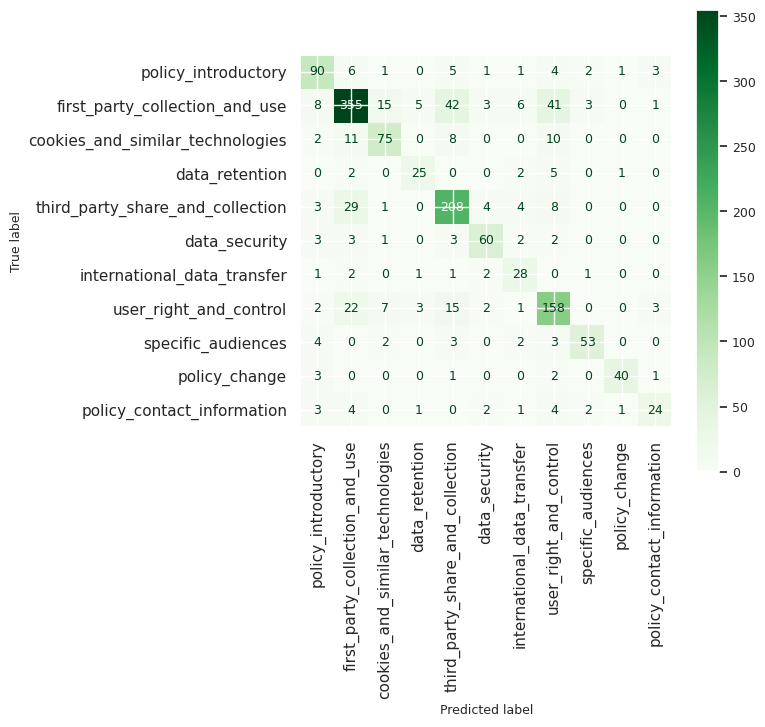

In [30]:
get_confusion_matrix(val_labels, y_pred, label_dict)

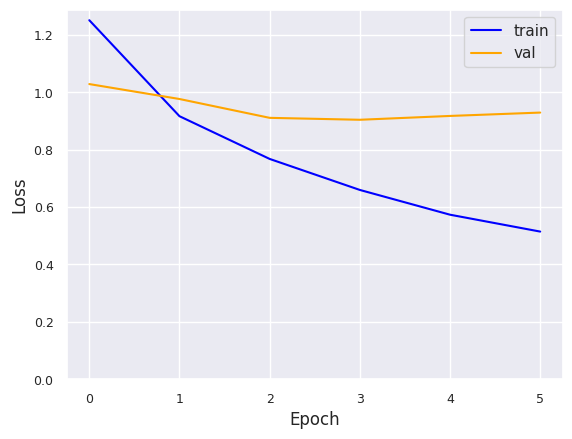

In [31]:
plot_metrics(train_loss_history, val_loss_history)

In [32]:
from transformers import AutoConfig

# configuration = AutoConfig.from_pretrained(MODEL_NAME)
# configuration.num_labels = NUM_LABELS
# configuration.output_attentions = False
# configuration.output_hidden_states = False
# configuration.classifier_dropout = DROPOUT


# model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME,
#                                                       config = configuration)

model = ROBERTAClassifier(DROPOUT)

model.to(device)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ROBERTAClassifier(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): L

In [33]:
epoch = 4
model.load_state_dict(torch.load( f'finetuned_V2_BERT_epoch_{epoch}.model', map_location=torch.device('cuda'))) # path_model

<All keys matched successfully>

In [34]:
_, predictions, true_vals = evaluate(dataloader_validation, WEIGHTED)
y_pred = predictions.argmax(axis=1)

In [35]:
print(classification_report(val_labels, y_pred, target_names=label_dict))

                                  precision    recall  f1-score   support

             policy_introductory       0.79      0.76      0.78       114
  first_party_collection_and_use       0.82      0.75      0.78       479
cookies_and_similar_technologies       0.74      0.71      0.72       106
                  data_retention       0.68      0.71      0.69        35
third_party_share_and_collection       0.74      0.80      0.77       257
                   data_security       0.78      0.82      0.80        74
     international_data_transfer       0.57      0.81      0.67        36
          user_right_and_control       0.66      0.74      0.70       213
              specific_audiences       0.87      0.78      0.82        67
                   policy_change       0.89      0.87      0.88        47
      policy_contact_information       0.71      0.57      0.63        42

                        accuracy                           0.76      1470
                       macro avg    

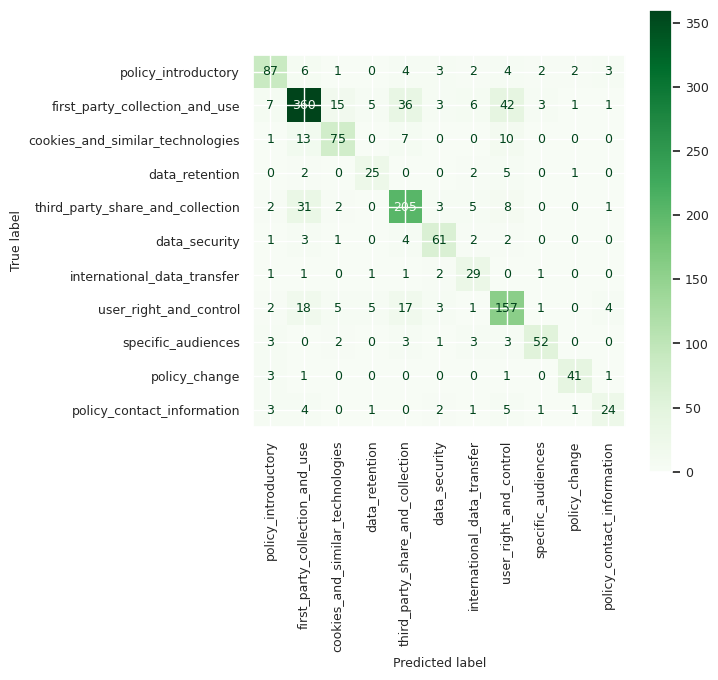

In [36]:
get_confusion_matrix(val_labels, y_pred, label_dict)

In [ ]:
path_model = '/content/drive/MyDrive/Memoria_Group_Classification/Modelos/'

epoch = 3

torch.save(model.state_dict(),path_model + f'finetuned_Roberta_epoch_{epoch}_BEST_MODEL.model')